1. **Plot and validate f(x)=2(x-1)^2+4**


Max error: 0.0
All close? True


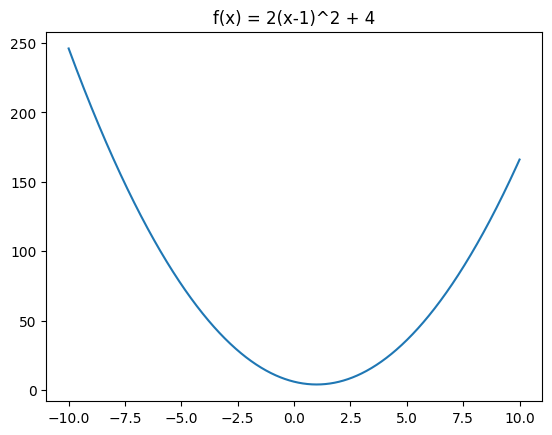

In [ ]:
# Plot and validate f(x)=2(x-1)^2+4
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Domain
x = np.linspace(-10, 10, 1000)

# NumPy computation
y_numpy = 2*(x - 1)**2 + 4

# SymPy → numeric
x_sym = sp.symbols("x")
expr = 2*(x_sym - 1)**2 + 4
f_sym = sp.lambdify(x_sym, expr, "numpy")
y_sympy = f_sym(x)

# Validation
error = np.max(np.abs(y_numpy - y_sympy))
print("Max error:", error)
print("All close?", np.allclose(y_numpy, y_sympy))

# Plot (single source of truth)
plt.plot(x, y_numpy)
plt.title("f(x) = 2(x-1)^2 + 4")
plt.show()

2. **How do you code f(x)=\sqrt{x+5} without breaking the domain?**
Focus on valid inputs and output shape.

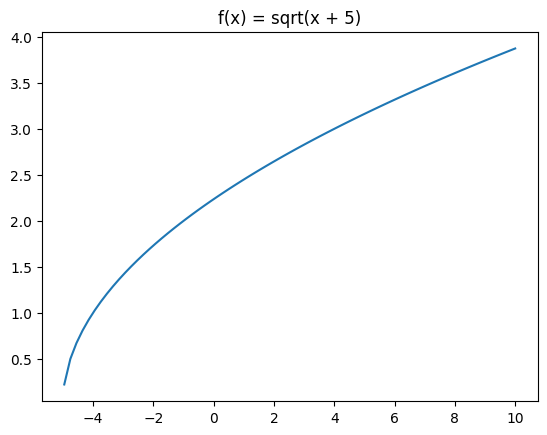

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 🔧 Domain
x = np.linspace(-10, 10, 100)

# 🔧 Mask valid inputs
mask = x >= -5

x_valid = x[mask]
y_valid = np.sqrt(x_valid + 5)

# 🔧 Plot
plt.plot(x_valid, y_valid)
plt.title("f(x) = sqrt(x + 5)")
plt.show()

----

1. **How do you implement a piecewise function on a NumPy array?**
   Example: if (x<0), use (x^2); if (0\le x<2), use (2x+1); otherwise use (\sqrt{x}).
   This forces masking and branching.'''

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 🔧 Input range
x = np.linspace(-20, 20, 1000)

# 🔧 Output array (same shape as x)
y = np.zeros_like(x)

# 🔧 Piecewise masks
mask1 = x < 0
mask2 = (x >= 0) & (x < 2)
mask3 = x >= 2

# 🔧 Apply piecewise definitions
y[mask1] = x[mask1]**2          # x^2
y[mask2] = 2*x[mask2] + 1      # 2x + 1
y[mask3] = np.sqrt(x[mask3])   # sqrt(x)

# 🔧 Plot
plt.figure()
plt.plot(x, y)
plt.title("Piecewise Function")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

2. **How do you build a function only on valid inputs and leave invalid inputs untouched?**
   Example: apply (\log(x-1)) only where (x>1), and mark the rest clearly.
   This trains domain filtering.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 50, 1000)

# 🔧 Fill everything as undefined initially
y = np.full_like(x, np.nan)

# 🔧 Valid domain
mask = x > 1

# 🔧 Compute only on valid region
y[mask] = np.log(x[mask] - 1)

# 🔧 Plot
plt.plot(x, y)
plt.axvline(x=2)
plt.grid()
plt.show()

3. **How do you compute a function, then reuse its output in a second rule?**
   Example: (y=f(x)), then if (y>3), square it; otherwise add 5.
   This is real pipeline logic.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 1000)

# 🔧 First function
y = x**2 - 2

# 🔧 Second rule
z = np.where(y > 3, y**2, y + 5)

# 🔧 Plot
plt.plot(x, z)

plt.grid()
plt.show()